# Irish Wind Speed Analysis Using Historic Met Éireann Weather Data

In [40]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Project dataset
In this project, I analyse wind speed data from across Ireland. To represent different regional conditions, data from the following weather stations has been selected:

- Malin Head (county Donegal) – north-west coastline
- Mace Head (county Galway) - Atlantic west coast 
- Dublin Airport (Dublin) - east coast

Historical wind speed data was obtained from [Met Éireann](https://www.met.ie/climate/available-data/historical-data). The data was downloaded locally and stored in the `data` folder within this project. Each folder contains the CSV file used for analysis, along with additional documentation and licence files, which are retained for reference and data governance purposes.

## Validate data repository structure

To load the datasets, the `pd.read_csv()` function requires the correct file paths. Before loading any data, the project directory is checked to confirm that the expected folders and CSV files are present.

A dictionary is created to store the data directory paths for each weather station, where the keys represent the station names and the values represent the corresponding folder locations. The contents of each directory are then printed using the `for loop` to verify that the required files are available. Iterating through the dictionary approach is adapted from the following [Real Python](https://realpython.com/iterate-through-dictionary-python/) tutorial.


In [2]:
# Create a dictionary to hold weather station data folders
data_dirs = {
    "Malin Head": "../project/data/malin_head/",
    "Mace Head": "../project/data/mace_head/",
    "Dublin Airport": "../project/data/dublin_airport/"
}

# List contents of each data directory using for loop
for station, path in data_dirs.items():
    print(f"\nContents of {station} directory:")
    !ls "{path}"


Contents of Malin Head directory:
Data_Licence.pdf Data_Licence.txt KeyHourly.txt    hly1575.csv

Contents of Mace Head directory:
Data_Licence.pdf Data_Licence.txt KeyHourly.txt    hly275.csv

Contents of Dublin Airport directory:
Data_Licence.pdf Data_Licence.txt KeyHourly.txt    hly532.csv


## Function for loading and normilizing data

Since multiple datasets are used in this project, a function is created to handle data loading in a consistent way.

Based on manual inspection of the CSV files, the function needs to account for the following:

- Each CSV file contains introductory metadata rows before the actual data begins, which should be skipped.  
  - Malin Head and Dublin Airport require skipping the first 23 rows  
  - Mace Head requires skipping the first 17 rows
- All datasets contain a common **"Date"** column. This column will be converted to datetime format and set as the DataFrame index to support time-based analysis.

Additionally, wind speed variable `wdsp` is the main focus of this analysis. To ensure reliably in further calculations, it is converted to numeric format. Any non-numeric or missing values are automatically converted to `NaN`.

In [3]:
def load_data(file_path, skiprows):
    """Load hourly weather data from a CSV file into a pandas DataFrame."""

    # Read the CSV file into a DataFrame using low_memory=False to avoid dtype warning
    df = pd.read_csv(file_path, skiprows=skiprows, low_memory=False)

    # Convert 'date' column to datetime 
    # format='mixed' handles different date formats - used to avoid pandas warning
    df['date']= pd.to_datetime(df['date'], format='mixed')
    
    # Convert wind speed to numeric (invalid values become NaN)
    df['wdsp'] = pd.to_numeric(df['wdsp'], errors='coerce')
    
    # Set 'date' column as index
    df = df.set_index('date')
    
    return df

## Load Malin Head dataset

In [4]:
# Define file path for Malin Head data
malin_data_dir = "../project/data/malin_head/"
malin_filename = "hly1575.csv"
malin_path = malin_data_dir + malin_filename

# Load Malin Head data (skip first 23 rows)
malin_df = load_data(malin_path, skiprows=23)

# Show first 5 rows
malin_df.head(5)

,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
date,,,,,,,,,,,,,,,,,,,,
1955-05-01 01:00:00,0,0.0,0,8.5,0,7.2,5.5,9.1,83,1005.6,0,11.0,0,130,3,2,0.0,30000,40,7
1955-05-01 02:00:00,0,0.0,0,8.2,0,7.2,6.1,9.3,85,1004.4,0,11.0,0,120,1,2,0.0,30000,100,6
1955-05-01 03:00:00,3,0.0,0,7.3,0,6.6,5.5,9.3,91,1003.8,0,8.0,0,120,1,2,0.0,30000,220,5
1955-05-01 04:00:00,3,0.0,0,7.8,0,7.2,6.1,9.6,91,1002.7,0,18.0,0,130,3,2,0.0,30000,90,7
1955-05-01 05:00:00,0,0.0,0,8.1,0,7.3,6.6,9.7,89,1002.1,0,9.0,0,110,2,2,0.0,40000,90,7


## Load Mace Head dataset

In [5]:
# Define file path for Mace Head data
mace_data_dir = "../project/data/mace_head/"
mace_filename = "hly275.csv"
mace_path = mace_data_dir + mace_filename

# Load Mace Head data (skip first 17 rows)
mace_df = load_data(mace_path, skiprows=17)

# Show first 5 rows
mace_df.head(5)

,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir
date,,,,,,,,,,,,,,
2003-08-13 01:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 02:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 03:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 04:00:00,-1,,4,,4,,,,,,7,NaN,7,
2003-08-13 05:00:00,-1,,4,,4,,,,,,7,NaN,7,


## Load Dublin Airport dataset

In [6]:
# Define file path for Dublin Airport data
dublin_data_dir = "../project/data/dublin_airport/"
dublin_filename = "hly532.csv"
dublin_path = dublin_data_dir + dublin_filename

# Load Dublin Airport data (skip first 23 rows)
dublin_df = load_data(dublin_path, skiprows=23)

# Show first 5 rows
dublin_df.head(5)

,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
date,,,,,,,,,,,,,,,,,,,,
1945-01-01 00:00:00,2,0.0,0,4.9,0,4.6,4.4,8.2,95,1035.8,1,0,1,0,50,4,0.0,200,2,8
1945-01-01 01:00:00,3,0.0,0,5.1,0,4.9,4.4,8.5,97,1035.8,1,0,1,0,45,4,0.0,200,2,8
1945-01-01 02:00:00,2,0.0,0,5.1,0,4.8,4.4,8.5,97,1035.8,1,0,1,0,50,4,0.0,4800,4,8
1945-01-01 03:00:00,0,0.2,0,5.2,0,5.0,4.4,8.5,97,1036.1,1,0,1,0,50,4,0.0,6000,4,8
1945-01-01 04:00:00,2,0.0,0,5.6,0,5.4,5.0,8.8,97,1036.2,1,7,1,250,50,5,0.0,6000,4,8


## Missing values in wind speed data
Since most of the subsequent analysis performed on the wind speed, the `wdsp` column is checked for missing values. The percentage of missing observations is calculated for each dataset using a method adapted from the following [Stack Overflow](https://stackoverflow.com/questions/51070985/find-out-the-percentage-of-missing-values-in-each-column-in-the-given-dataset) discussion.

In [7]:
missing_pct = malin_df["wdsp"].isna().sum() * 100 / len(malin_df)

print(f"Malin dataet - missing wind speed values: {missing_pct:.2f}%")

Malin dataet - missing wind speed values: 0.01%


In [8]:
missing_pct = mace_df["wdsp"].isna().mean() * 100 / len(mace_df)

print(f"Mace dataset - missing wind speed values: {missing_pct:.2f}%")

Mace dataset - missing wind speed values: 0.00%


In [9]:
missing_pct = dublin_df["wdsp"].isna().mean() * 100 / len(dublin_df)

print(f"Dublin dataset - missing wind speed values: {missing_pct:.2f}%")

Dublin dataset - missing wind speed values: 0.00%


The results show that the proportion of missing wind speed values is low across all datasets. Therefore, missing values are left as `NaN`, as pandas automatically excludes them from most calculations.

## Descriptive statistics of wind speed

Summary statistics are calculated for the wind speed variable to provide an overview of central tendency and variability at each station.

In [10]:
# Malin Head descriptive statistics
malin_df['wdsp'].describe()

count    618716.000000
mean         15.209167
std           7.816141
min           0.000000
25%           9.000000
50%          14.000000
75%          20.000000
max          63.000000
Name: wdsp, dtype: float64

At **Malin Head**, the mean wind speed is ~15.2 knots, with a median of 14 knots. There's relatively high standard deviation of 7.8 knots along with a wide range of values indicating variability in wind conditions. Extreme wind speeds reach up to 63 knots, reflecting the exposed north-west coastal location.

In [11]:
# Mace Head descriptive statistics
mace_df['wdsp'].describe()

count    194208.000000
mean         14.480330
std           7.551301
min           0.000000
25%           9.000000
50%          14.000000
75%          19.000000
max          72.000000
Name: wdsp, dtype: float64

For **Mace Head**, the mean wind speed is slightly lower at ~14.5 knots, with the similar median of 14 knots and a standard deviation of 7.6 knots. The maximum recorded value of 72 knots indicates occasional very strong wind events, consistent with its Atlantic coastal position.

In [12]:
# Dublin Airport descriptive statistics
dublin_df['wdsp'].describe()

count    709297.000000
mean         10.114264
std           5.680150
min           0.000000
25%           6.000000
50%           9.000000
75%          14.000000
max          46.000000
Name: wdsp, dtype: float64

**Dublin Airport** shows lower overall wind speeds. The mean wind speed is approximately 10.1 knots, with a median of 9 knots. The lower standard deviation (5.7 knots) and smaller maximum value (46 knots) suggest less variability and fewer extreme wind events compared to the coastal stations. 

## Wind speed distribution

To further explore overall behaviour of wind speed at each location, the data is visualised using histograms created with `Matplotlib`. Histograms will show the frequency of different wind speed values in the detaset and will help to illustrate the distribution, spread, and skewness of each dataset.

### Malin Head

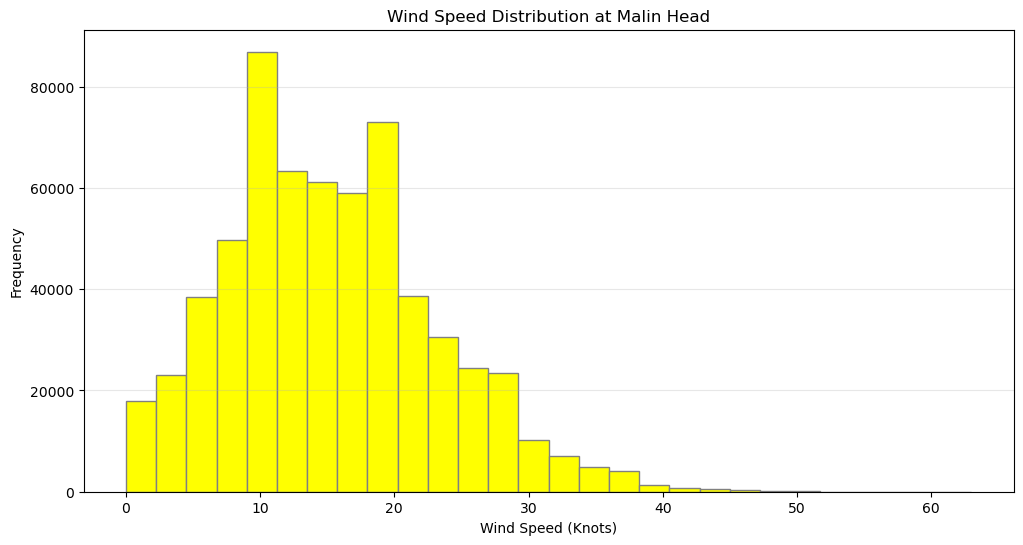

In [13]:
# Plot histogram of wind speed for Malin Head
plt.figure(figsize=(12, 6))

plt.hist(malin_df['wdsp'], bins=28, color='yellow', edgecolor='grey')
plt.title('Wind Speed Distribution at Malin Head')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

The histogram for Malin Head shows that most wind speed values are concentrated in the range of approximately 9-20 knots, with the median value of 14 knots located close to the centre of this range. The distribution displays a slight right skew, indicating that higher wind speeds occur less frequently, with a tail extending to a maximum value of 63 knots. The wide spread of values and a relatively high standard deviation reflect the exposed nature of the north-west coastal location.

### Mace Head

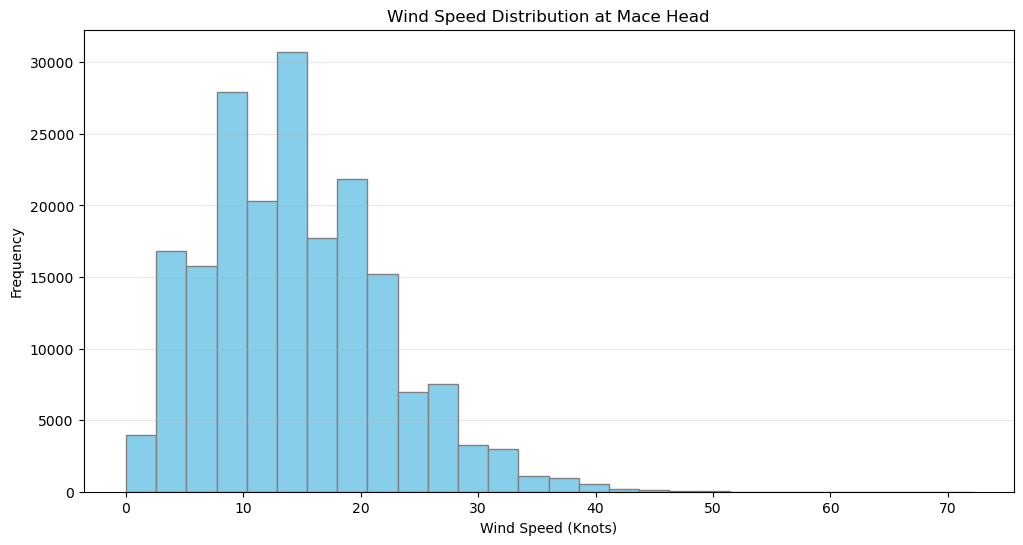

In [14]:
# Plot histogram of wind speed for Mace Head
plt.figure(figsize=(12, 6))

plt.hist(mace_df['wdsp'], bins=28, color='skyblue', edgecolor='grey')
plt.title('Wind Speed Distribution at Mace Head')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

The histogram for Mace Head shows a similar overall pattern to Malin Head, with most wind speed values falling between approximately 9 and 19 knots and a median wind speed of 14 knots. The distribution is slightly right-skewed, with occasional high wind events extending up to a maximum of 72 knots. The relatively large spread and variability reflect the exposed Atlantic coastal environment.

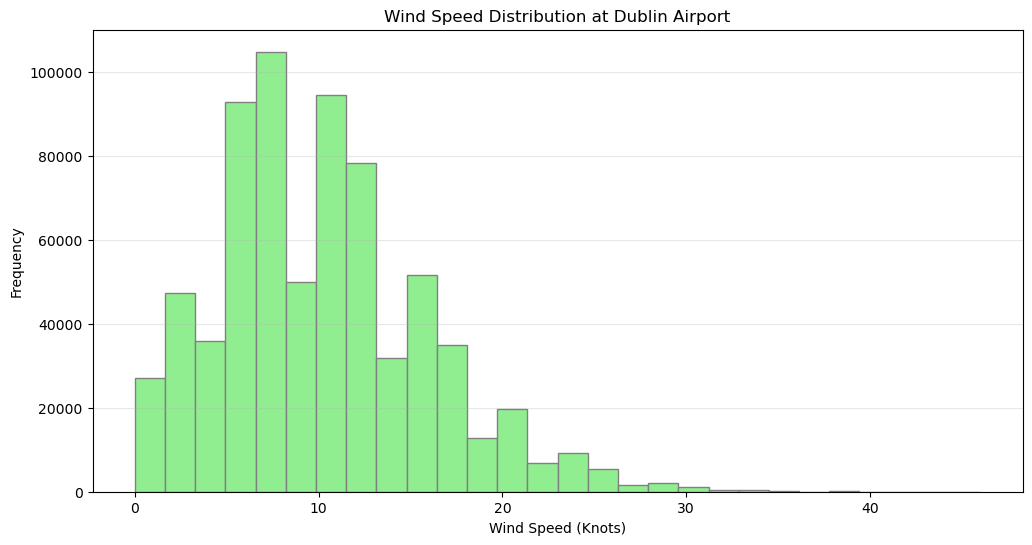

In [15]:
# Plot histogram of wind speed for Dublin Airport
plt.figure(figsize=(12, 6))

plt.hist(dublin_df['wdsp'], bins=28, color='lightgreen', edgecolor='grey')
plt.title('Wind Speed Distribution at Dublin Airport')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

The histogram for Dublin Airport differs from the coastal stations, with most wind speeds concentrated between approximately 6 and 14 knots and the median wind speed of 9 knots, which is lower than at the coastal locations.

Although the distribution also shows a slight right skew, the overall spread is narrower and the maximum recorded wind speed (46 knots) is considerably lower. This indicates less variable and weaker wind conditions, which is expected given Dublin Airport’s more sheltered inland location.


## Wind speed ranges

According to the Wikipedia page on [Wind turbine design](https://en.wikipedia.org/wiki/Wind_turbine_design?utm_source=chatgpt.com), turbines generate usable power only within specific wind speed ranges. A minimum cut-in speed of approximately 3–4 metres per second is required for operation, while turbines shut down at  speeds above the cut-out threshold of around 25 metres per second for safety reasons. 

Converted to knots using [XConvert](https://www.xconvert.com/unit-converter/metres-per-second-to-knots/?measure=speed&value=3) based on the above thresholds: 
- **Cut-in speed**: ~5.8 knots.
- **Cut-out speed**: ~48.6 knots. 

Based on these values, wind speeds at each weather station can be grouped into operational ranges: 
- **Below cut-in speed (<5.8kt)**: turbine does not operate. 
- **Operating range (>=5.8kt and <= 48.6kt)**: turbine can generate power.
- **Above cut-out speed (>48.6kt)**: turbine shuts down for safety.

Using these ranges, I can define a function that will calculate how often wind conditions at each location fall within the operational range.

In [ ]:
def wind_power_ranges(df, location):
    """Categorize wind power for a given location and return percentages."""

    # Count hours (number of rows) in each wind speed range using shape method
    below_cut_in = df[df['wdsp'] < 5.8].shape[0]
    operational_range = df[(df['wdsp'] >= 5.8) & (df['wdsp'] <= 48.6)].shape[0]
    above_cut_out = df[df['wdsp'] > 48.6].shape[0]

    total_hours = below_cut_in + operational_range + above_cut_out
    
    # Calculate percentages
    below_cut_in_pct = (below_cut_in / total_hours) * 100
    operational_pct = (operational_range / total_hours) * 100
    above_cut_out_pct = (above_cut_out / total_hours) * 100
    
    # Return results as a dictionary
    return {
        "location": location,
        "below_cut_in_pct": below_cut_in_pct,
        "operational_pct": operational_pct,
        "above_cut_out_pct": above_cut_out_pct
    }

To compare the percentage of hours within each wind speed range across stations, results from each location are stored in dictionaries and then combined into a single pandas DataFrame. Converting a list of dictionaries to a DataFrame was followed using the [Geeks For Geeks](https://www.geeksforgeeks.org/python/create-a-pandas-dataframe-from-list-of-dicts/?utm_source=chatgpt.com) explanation.

In [ ]:
# Call function for each location and store results
malin_results = wind_power_ranges(malin_df, "Malin Head")
mace_results = wind_power_ranges(mace_df, "Mace Head")
dublin_results = wind_power_ranges(dublin_df, "Dublin Airport")

# Combine all results into a list
all_results = [malin_results, mace_results, dublin_results]

In [ ]:
# Create a DataFrame to compare results
df_comparison = pd.DataFrame(all_results)

# Show combined results as dataframe
df_comparison

,location,below_cut_in_pct,operational_pct,above_cut_out_pct
0,Malin Head,9.391385,90.577583,0.031032
1,Mace Head,10.702958,89.269752,0.027290
2,Dublin Airport,21.721507,78.278493,0.000000


### Visualise wind speed ranges at each location

A stacked bar chart is used to compare how wind speeds at each location fall within the defined operational ranges. 

The stacked bar chart approach is informed by this [Python Charts](https://www.pythoncharts.com/matplotlib/stacked-bar-charts-labels/) guide.

/var/folders/1p/6wv_t6950nn3j0pyj38w2cxr0000gn/T/ipykernel_4633/2941435678.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


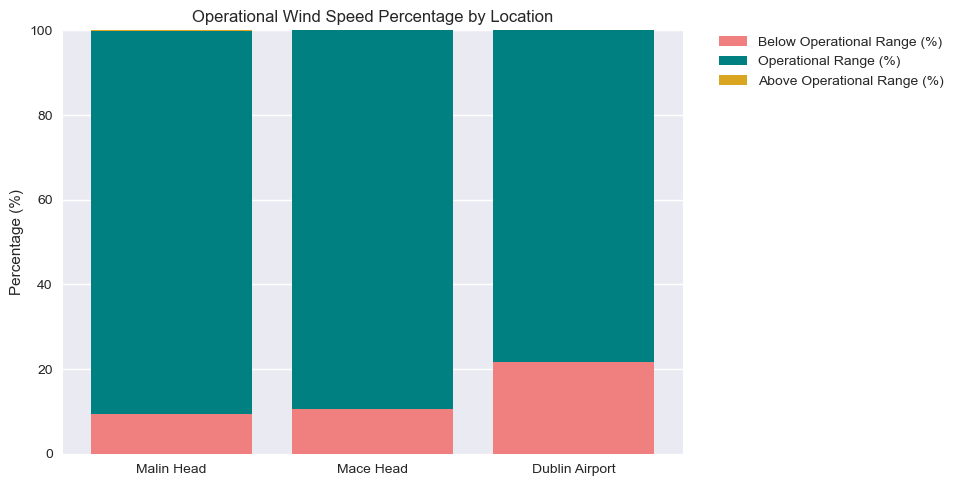

In [54]:
# Create stacked bar chart to compare operational wind power ranges across locations 
plt.style.use('seaborn')

fig, ax = plt.subplots()
ax.bar(df_comparison['location'], df_comparison['below_cut_in_pct'], label='Below Operational Range (%)', color='lightcoral')
ax.bar(df_comparison['location'], df_comparison['operational_pct'], bottom=df_comparison['below_cut_in_pct'], label='Operational Range (%)', color='teal')
ax.bar(df_comparison['location'], df_comparison['above_cut_out_pct'], bottom=df_comparison['below_cut_in_pct'] + df_comparison['operational_pct'], label='Above Operational Range (%)', color='goldenrod')
ax.set_title('Operational Wind Speed Percentage by Location')
ax.set_ylabel('Percentage (%)')
# Place legend outside the plot area
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.0
    )
plt.show()


Based on the above visualisation, the following observations are aparent: 
- Coastal locations have a higher proportion of operational wind hours
- Dublin Airport has a larger share below cut-in speed due to its shelterred inland location
- Cut-out events are rare across all stations

## End